In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, OneHotEncoder 
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
import kagglehub
import optuna

/home/orlandojunior/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.competition_download('playground-series-s6e8')

print("Path to competition files:", path)

Path to competition files: /home/orlandojunior/.cache/kagglehub/competitions/playground-series-s6e8


## Leitura dos dados

In [3]:
df_train = pd.read_csv(f"{path}/train.csv")
df_test = pd.read_csv(f"{path}/test.csv")

In [4]:
df_train.isna().sum()/len(df_train)

id                         0.000000
age                        0.041843
daily_screen_time_hours    0.138644
social_media_hours         0.193811
gaming_hours               0.183435
work_study_hours           0.074516
sleep_hours                0.064336
notifications_per_day      0.097754
app_opens_per_day          0.116739
weekend_screen_time        0.162089
gender                     0.041995
stress_level               0.079766
academic_work_impact       0.063966
addicted_label             0.000000
dtype: float64

In [5]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  str    
 11  stress_level             636221 non-null  str    
 12  academic_work_impact     647145 non-null  str    
 13  addicted_label           691369 non-null  int64  
dtypes: float64(9), 

## EDA

In [6]:
colunas_categoricas = df_train.select_dtypes(include=['str']).columns

for col in colunas_categoricas:
    print(f"{col} - {df_train[col].unique()}")

gender - <StringArray>
['Male', 'Female', 'Other', nan]
Length: 4, dtype: str
stress_level - <StringArray>
['Medium', 'Low', 'High', nan]
Length: 4, dtype: str
academic_work_impact - <StringArray>
['No', 'Yes', nan]
Length: 3, dtype: str


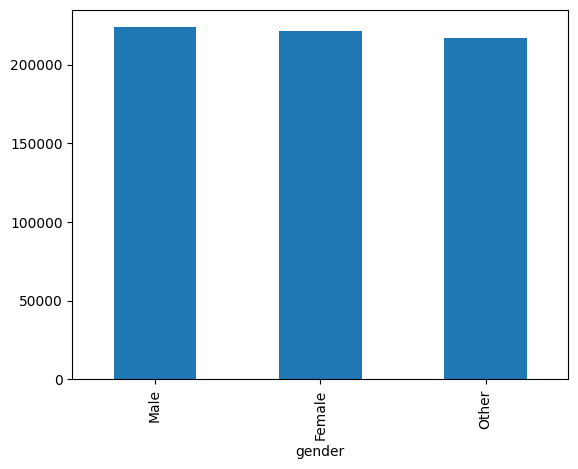

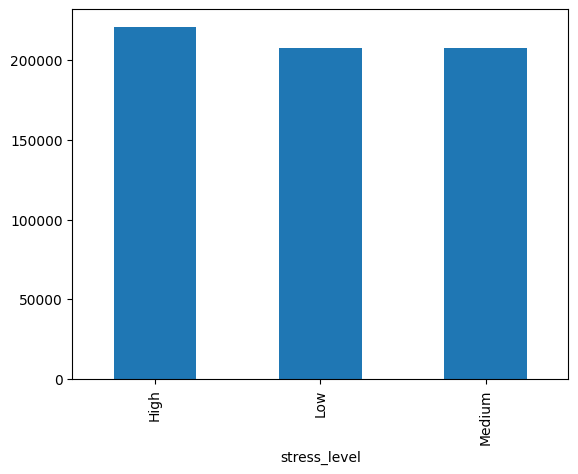

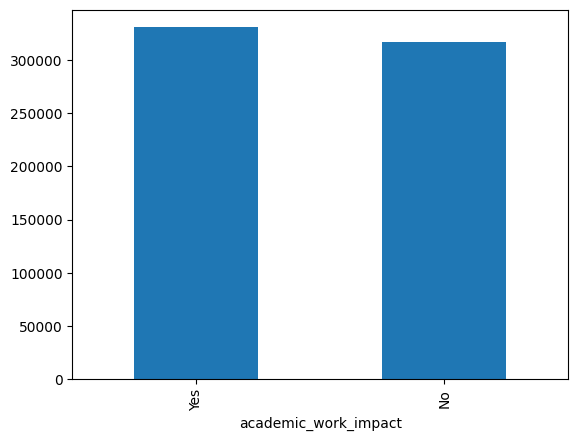

In [7]:
for col in colunas_categoricas:
    fig = df_train[col].value_counts().plot.bar()
    plt.show()

In [8]:
df_test.isna().sum()/len(df_test)

id                         0.000000
age                        0.057840
daily_screen_time_hours    0.110657
social_media_hours         0.159962
gaming_hours               0.200539
work_study_hours           0.093746
sleep_hours                0.075784
notifications_per_day      0.115494
app_opens_per_day          0.086753
weekend_screen_time        0.171099
gender                     0.047965
stress_level               0.066236
academic_work_impact       0.086807
dtype: float64

In [9]:
colunas_numericas = df_train.select_dtypes(include=['number']).columns
colunas_numericas

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'addicted_label'],
      dtype='str')

In [10]:
df_train[colunas_numericas].describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183467,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [11]:
df_train[colunas_numericas].describe()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
count,691369.000000,662440.000000,595515.000000,557374.000000,564548.000000,639851.000000,646889.000000,623785.000000,610659.000000,579306.000000,691369.000000
mean,345684.000000,26.615408,7.640865,2.471038,1.459265,2.366971,6.804334,145.894900,102.636781,9.479866,0.709424
std,199581.183467,5.153162,2.721446,1.316137,0.934552,1.258797,1.234512,65.917556,48.093970,2.856006,0.454028
min,0.000000,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000
25%,172842.000000,22.000000,5.480000,1.450000,0.700000,1.360000,5.780000,93.000000,64.000000,7.280000,0.000000
50%,345684.000000,27.000000,7.770000,2.310000,1.330000,2.200000,6.800000,150.000000,104.000000,9.580000,1.000000
75%,518526.000000,31.000000,9.840000,3.370000,2.090000,3.200000,7.870000,204.000000,145.000000,11.750000,1.000000
max,691368.000000,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000


In [12]:
colunas_numericas

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'addicted_label'],
      dtype='str')

In [13]:
sp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
sp_mode = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

cols_to_scaler = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours',
       'work_study_hours', 'sleep_hours', 'notifications_per_day',
       'app_opens_per_day', 'weekend_screen_time']
cols_to_oneHot = ['gender', 'stress_level', 'academic_work_impact']

df_train[cols_to_scaler] = sp_mean.fit_transform(df_train[cols_to_scaler])
df_train[cols_to_oneHot] = sp_mode.fit_transform(df_train[cols_to_oneHot])

df_test[cols_to_scaler] = sp_mean.transform(df_test[cols_to_scaler])
df_test[cols_to_oneHot] = sp_mode.transform(df_test[cols_to_oneHot])

df_train.isna().sum()

id                         0
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
gender                     0
stress_level               0
academic_work_impact       0
addicted_label             0
dtype: int64

In [14]:
df_test.isna().sum()

id                         0
age                        0
daily_screen_time_hours    0
social_media_hours         0
gaming_hours               0
work_study_hours           0
sleep_hours                0
notifications_per_day      0
app_opens_per_day          0
weekend_screen_time        0
gender                     0
stress_level               0
academic_work_impact       0
dtype: int64

In [15]:
def feature_engineering(df):
    df_fe = df.copy()
    
    # Epsilon para evitar divisão por zero e geração de infinitos (inf)
    eps = 1e-5
    
    # 1. Comportamento e Impulsividade
    df_fe['dailyScreenTime_appOpens'] = df_fe['daily_screen_time_hours'] / (df_fe['app_opens_per_day'] + eps)
    df_fe['opens_per_notification'] = df_fe['app_opens_per_day'] / (df_fe['notifications_per_day'] + eps)
    df_fe['notific_per_screen_hour'] = df_fe['notifications_per_day'] / (df_fe['daily_screen_time_hours'] + eps)
    
    # 2. Proporções de Uso em relação ao tempo total (daily_screen_time_hours)
    df_fe['social_ratio'] = df_fe['social_media_hours'] / (df_fe['daily_screen_time_hours'] + eps)
    df_fe['gaming_ratio'] = df_fe['gaming_hours'] / (df_fe['daily_screen_time_hours'] + eps)
    df_fe['work_study_ratio'] = df_fe['work_study_hours'] / (df_fe['daily_screen_time_hours'] + eps)
    
    # Razão de Lazer vs Produtividade
    df_fe['leisure_vs_work'] = (df_fe['social_media_hours'] + df_fe['gaming_hours']) / (df_fe['work_study_hours'] + eps)
    
    # 3. Tempo "Outros" (Atividades não categorizadas em Social, Gaming ou Work)
    df_fe['other_screen_time'] = df_fe['daily_screen_time_hours'] - (df_fe['social_media_hours'] + df_fe['gaming_hours'] + df_fe['work_study_hours'])
    df_fe['other_screen_time'] = df_fe['other_screen_time'].clip(lower=0) # Garante que não fique negativo
    
    # 4. Estilo de vida e Sono
    df_fe['awake_hours'] = 24 - df_fe['sleep_hours']
    # Qual % do dia acordado é gasto na tela?
    df_fe['screen_time_awake_ratio'] = df_fe['daily_screen_time_hours'] / (df_fe['awake_hours'] + eps)
    
    # 5. Diferença Fim de semana vs Dia de semana
    df_fe['weekend_diff_hours'] = df_fe['weekend_screen_time'] - df_fe['daily_screen_time_hours']
    df_fe['weekend_ratio'] = df_fe['weekend_screen_time'] / (df_fe['daily_screen_time_hours'] + eps)

    cols_to_remove = ['id']
    df_fe = df_fe.drop(columns=cols_to_remove, errors='ignore')
    
    return df_fe


ids = df_test['id']
df_train = feature_engineering(df_train)
df_test = feature_engineering(df_test)
df = pd.concat([df_train, df_test], axis=0, sort=False)

## Preparar os dados

In [16]:
df.info()

<class 'pandas.DataFrame'>
Index: 987671 entries, 0 to 296301
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   age                       987671 non-null  float64
 1   daily_screen_time_hours   987671 non-null  float64
 2   social_media_hours        987671 non-null  float64
 3   gaming_hours              987671 non-null  float64
 4   work_study_hours          987671 non-null  float64
 5   sleep_hours               987671 non-null  float64
 6   notifications_per_day     987671 non-null  float64
 7   app_opens_per_day         987671 non-null  float64
 8   weekend_screen_time       987671 non-null  float64
 9   gender                    987671 non-null  str    
 10  stress_level              987671 non-null  str    
 11  academic_work_impact      987671 non-null  str    
 12  addicted_label            691369 non-null  float64
 13  dailyScreenTime_appOpens  987671 non-null  float64
 14  open

In [17]:
df.describe()

,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label,...,notific_per_screen_hour,social_ratio,gaming_ratio,work_study_ratio,leisure_vs_work,other_screen_time,awake_hours,screen_time_awake_ratio,weekend_diff_hours,weekend_ratio
count,987671.000000,987671.000000,987671.000000,987671.000000,987671.000000,987671.000000,987671.000000,987671.000000,987671.000000,691369.000000,...,987671.000000,987671.000000,987671.000000,987671.000000,987671.000000,987671.000000,987671.000000,987671.000000,987671.000000,987671.000000
mean,26.613509,7.640840,2.471085,1.458882,2.366697,6.803605,145.855937,102.642106,9.478551,0.709424,...,22.494128,0.334896,0.200922,0.321376,2.699461,1.443739,17.196395,0.446749,1.837710,1.339048
std,5.031605,2.539314,1.189712,0.841887,1.206705,1.192397,62.455120,45.455986,2.610742,0.454028,...,17.471267,0.155469,0.115374,0.150068,291.031859,1.561422,1.192397,0.152618,1.978762,0.557716
min,18.000000,0.500000,0.000000,0.000000,0.000000,4.500000,20.000000,15.000000,0.510000,0.000000,...,1.374570,0.000000,0.000000,0.000000,0.000000,0.000000,15.000000,0.025654,-7.910000,0.085427
25%,22.000000,5.790000,1.640000,0.840000,1.430000,5.860000,102.000000,68.000000,7.720000,0.000000,...,12.532342,0.238747,0.125211,0.215242,1.139215,0.400000,16.230000,0.335808,0.540000,1.065540
50%,26.615408,7.640865,2.471038,1.459265,2.350000,6.804334,145.894900,102.636781,9.479866,1.000000,...,19.094003,0.323397,0.190981,0.314990,1.660786,0.828962,17.195666,0.446370,1.839001,1.240678
75%,31.000000,9.600000,3.120000,1.890000,3.100000,7.770000,197.000000,140.000000,11.330000,1.000000,...,27.851459,0.416413,0.268247,0.412718,2.666651,2.060000,18.140000,0.559799,3.100000,1.463284
max,35.000000,15.000000,8.000000,4.000000,6.000000,9.000000,250.000000,180.000000,17.560000,1.000000,...,499.990000,4.941978,2.918471,4.733847,249103.820774,11.990000,19.500000,0.869986,11.490000,20.439591


## Pré-processamento

In [18]:
preprocessing = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), cols_to_scaler),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cols_to_oneHot)
    ],
    remainder="passthrough"
)

df_preprocessing = preprocessing.fit_transform(df)
names_columns = preprocessing.get_feature_names_out()

new_df = pd.DataFrame(data=df_preprocessing,columns=names_columns)

In [19]:
new_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 987671 entries, 0 to 987670
Data columns (total 30 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   scaler__age                          987671 non-null  float64
 1   scaler__daily_screen_time_hours      987671 non-null  float64
 2   scaler__social_media_hours           987671 non-null  float64
 3   scaler__gaming_hours                 987671 non-null  float64
 4   scaler__work_study_hours             987671 non-null  float64
 5   scaler__sleep_hours                  987671 non-null  float64
 6   scaler__notifications_per_day        987671 non-null  float64
 7   scaler__app_opens_per_day            987671 non-null  float64
 8   scaler__weekend_screen_time          987671 non-null  float64
 9   encoder__gender_Female               987671 non-null  float64
 10  encoder__gender_Male                 987671 non-null  float64
 11  encoder__gender_Other   

In [20]:
df_train.shape, df_test.shape

((691369, 25), (296302, 24))

In [21]:
df_training = new_df[:df_train.shape[0]]
df_testing = new_df[df_train.shape[0]:]

In [22]:
df_testing.info()

<class 'pandas.DataFrame'>
RangeIndex: 296302 entries, 691369 to 987670
Data columns (total 30 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   scaler__age                          296302 non-null  float64
 1   scaler__daily_screen_time_hours      296302 non-null  float64
 2   scaler__social_media_hours           296302 non-null  float64
 3   scaler__gaming_hours                 296302 non-null  float64
 4   scaler__work_study_hours             296302 non-null  float64
 5   scaler__sleep_hours                  296302 non-null  float64
 6   scaler__notifications_per_day        296302 non-null  float64
 7   scaler__app_opens_per_day            296302 non-null  float64
 8   scaler__weekend_screen_time          296302 non-null  float64
 9   encoder__gender_Female               296302 non-null  float64
 10  encoder__gender_Male                 296302 non-null  float64
 11  encoder__gender_Oth

In [23]:
df_testing = df_testing.drop(columns=['remainder__addicted_label'])

In [24]:
df_testing.info()

<class 'pandas.DataFrame'>
RangeIndex: 296302 entries, 691369 to 987670
Data columns (total 29 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   scaler__age                          296302 non-null  float64
 1   scaler__daily_screen_time_hours      296302 non-null  float64
 2   scaler__social_media_hours           296302 non-null  float64
 3   scaler__gaming_hours                 296302 non-null  float64
 4   scaler__work_study_hours             296302 non-null  float64
 5   scaler__sleep_hours                  296302 non-null  float64
 6   scaler__notifications_per_day        296302 non-null  float64
 7   scaler__app_opens_per_day            296302 non-null  float64
 8   scaler__weekend_screen_time          296302 non-null  float64
 9   encoder__gender_Female               296302 non-null  float64
 10  encoder__gender_Male                 296302 non-null  float64
 11  encoder__gender_Oth

In [25]:
df_training.info()

<class 'pandas.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 30 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   scaler__age                          691369 non-null  float64
 1   scaler__daily_screen_time_hours      691369 non-null  float64
 2   scaler__social_media_hours           691369 non-null  float64
 3   scaler__gaming_hours                 691369 non-null  float64
 4   scaler__work_study_hours             691369 non-null  float64
 5   scaler__sleep_hours                  691369 non-null  float64
 6   scaler__notifications_per_day        691369 non-null  float64
 7   scaler__app_opens_per_day            691369 non-null  float64
 8   scaler__weekend_screen_time          691369 non-null  float64
 9   encoder__gender_Female               691369 non-null  float64
 10  encoder__gender_Male                 691369 non-null  float64
 11  encoder__gender_Other   

In [26]:
X = df_training.drop(columns=['remainder__addicted_label'])
y = df_training['remainder__addicted_label']

In [27]:
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.3,shuffle=True,stratify=y,random_state=0)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.5,shuffle=True,stratify=y_temp,random_state=0)

X_train.shape, X_test.shape, X_val.shape

((483958, 29), (103706, 29), (103705, 29))

In [28]:
def objective(trial):

    params = {
        "n_estimators": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "eval_metric": "logloss",
        "early_stopping_rounds": 5,
        "n_jobs": -1,
        "tree_method": "hist",
        "device": "cuda"
    }
    
    model = XGBClassifier(**params)
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_proba = model.predict_proba(X_val)[:, 1]
    
    score = roc_auc_score(y_val, y_proba)
    
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)


[I 2026-08-08 14:58:45,472] A new study created in memory with name: no-name-aee8fdc6-ec01-4943-b4d6-671daddede3e
/home/orlandojunior/miniconda3/lib/python3.13/site-packages/xgboost/core.py:553: UserWarning: [14:58:49] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
[I 2026-08-08 14:58:50,013] Trial 0 finished with value: 0.9542651385608397 and parameters: {'learning_rate': 0.016950662379973842, 'max_depth': 5, 'subsample': 0.8051534564389828, 'colsample_bytree': 0.7191431280686156, 'min_child_weight': 10}. Best is trial 0 with value: 0.9542651385608397.
[I 2026-08-08 14:

In [29]:
fixed_params = {
    "n_estimators": 1000,
    "eval_metric": "logloss",
    "early_stopping_rounds": 5,
    "n_jobs": -1,
    "tree_method": "hist",
    "device": "cuda"
}

final_params = {**fixed_params, **study.best_params}
best_model = XGBClassifier(**final_params)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True 
)

[0]	validation_0-logloss:0.58153
[1]	validation_0-logloss:0.56226
[2]	validation_0-logloss:0.54469
[3]	validation_0-logloss:0.52861
[4]	validation_0-logloss:0.51373
[5]	validation_0-logloss:0.50029
[6]	validation_0-logloss:0.48778
[7]	validation_0-logloss:0.47591
[8]	validation_0-logloss:0.46497
[9]	validation_0-logloss:0.45485
[10]	validation_0-logloss:0.44540
[11]	validation_0-logloss:0.43652
[12]	validation_0-logloss:0.42812
[13]	validation_0-logloss:0.42033
[14]	validation_0-logloss:0.41301
[15]	validation_0-logloss:0.40612
[16]	validation_0-logloss:0.39957
[17]	validation_0-logloss:0.39343
[18]	validation_0-logloss:0.38766
[19]	validation_0-logloss:0.38221
[20]	validation_0-logloss:0.37705
[21]	validation_0-logloss:0.37218
[22]	validation_0-logloss:0.36760
[23]	validation_0-logloss:0.36322
[24]	validation_0-logloss:0.35908
[25]	validation_0-logloss:0.35515
[26]	validation_0-logloss:0.35147
[27]	validation_0-logloss:0.34796
[28]	validation_0-logloss:0.34465
[29]	validation_0-loglos

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8454069987902699
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",5
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

In [30]:
preds = best_model.predict(X_test)
preds

array([1, 1, 1, ..., 1, 1, 1], shape=(103706,))

<Axes: >

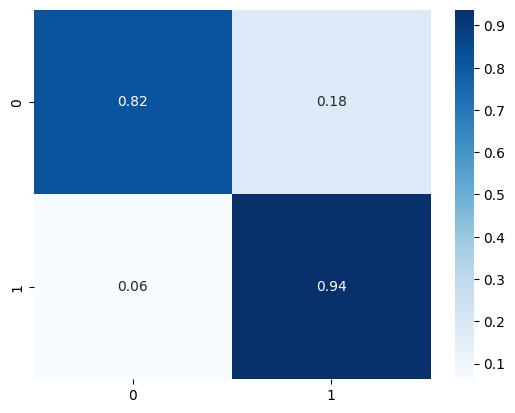

In [31]:
cm = confusion_matrix(y_test, preds, normalize="true")

sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)


  accuracy                           0.90

In [32]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         0.0       0.84      0.82      0.83     30135
         1.0       0.93      0.94      0.93     73571

    accuracy                           0.90    103706
   macro avg       0.88      0.88      0.88    103706
weighted avg       0.90      0.90      0.90    103706



0.8766534733735254

In [33]:
print(roc_auc_score(y_test, preds))

0.8766534733735254


In [34]:
preds_final = best_model.predict_proba(df_testing)
preds_final = preds_final[:,1]
preds_final

array([0.99912375, 0.95910305, 0.941518  , ..., 0.19604333, 0.7760079 ,
       0.7583956 ], shape=(296302,), dtype=float32)

In [35]:
df_result = pd.DataFrame({"id": ids, "addicted_label":preds_final})

df_result.to_csv("submission.csv", index=False)